<a href="https://colab.research.google.com/github/nilanjana310/-GAN-ai-based-image-generation/blob/main/Copy_of_assign6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

In [ ]:
class ShapeDataset(Dataset):
    def __init__(self, num_samples=2000, img_size=28):
        self.img_size = img_size
        self.data = []
        self.labels = []

        for _ in range(num_samples):
            label = np.random.randint(0, 2)
            img = np.zeros((img_size, img_size))

            if label == 0:
                cx, cy = img_size//2, img_size//2
                r = img_size//4
                for x in range(img_size):
                    for y in range(img_size):
                        if (x - cx)**2 + (y - cy)**2 < r**2:
                            img[x, y] = 1
            else:
                s = img_size//4
                img[img_size//2 - s:img_size//2 + s,
                    img_size//2 - s:img_size//2 + s] = 1

            self.data.append(img)
            self.labels.append(label)

        self.data = np.array(self.data)
        self.labels = np.array(self.labels)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = self.data[idx]
        img = (img - 0.5) / 0.5
        return torch.tensor(img, dtype=torch.float32).view(-1), torch.tensor(self.labels[idx])

In [ ]:
class Generator(nn.Module):
    def __init__(self, noise_dim, num_classes):
        super().__init__()

        self.label_emb = nn.Embedding(num_classes, 50)

        self.model = nn.Sequential(
            nn.Linear(noise_dim + 50, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        label_input = self.label_emb(labels)
        x = torch.cat((noise, label_input), dim=1)
        return self.model(x)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.label_emb = nn.Embedding(num_classes, 50)

        self.model = nn.Sequential(
            nn.Linear(784 + 50, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        label_input = self.label_emb(labels)
        x = torch.cat((img, label_input), dim=1)
        return self.model(x)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

noise_dim = 50
num_classes = 2
batch_size = 64

dataset = ShapeDataset()
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

G = Generator(noise_dim, num_classes).to(device)
D = Discriminator(num_classes).to(device)

criterion = nn.BCELoss()

optimizer_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [ ]:
epochs = 50

for epoch in range(epochs):
    for real_imgs, labels in loader:
        real_imgs, labels = real_imgs.to(device), labels.to(device)
        batch_size = real_imgs.size(0)

        real = torch.ones(batch_size, 1).to(device)
        fake = torch.zeros(batch_size, 1).to(device)


        z = torch.randn(batch_size, noise_dim).to(device)
        gen_labels = torch.randint(0, num_classes, (batch_size,)).to(device)
        fake_imgs = G(z, gen_labels)

        real_loss = criterion(D(real_imgs, labels), real)
        fake_loss = criterion(D(fake_imgs.detach(), gen_labels), fake)


        wrong_labels = torch.randint(0, num_classes, (batch_size,)).to(device)
        wrong_loss = criterion(D(real_imgs, wrong_labels), fake)

        d_loss = real_loss + fake_loss + 0.5 * wrong_loss

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        gen_imgs = G(z, gen_labels)
        g_loss = criterion(D(gen_imgs, gen_labels), real)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

    print(f"Epoch {epoch+1}/{epochs} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

Epoch 1/50 | D Loss: 1.1644 | G Loss: 1.4033
Epoch 2/50 | D Loss: 0.8116 | G Loss: 2.5641
Epoch 3/50 | D Loss: 1.2307 | G Loss: 1.8007
Epoch 4/50 | D Loss: 1.4573 | G Loss: 0.9875
Epoch 5/50 | D Loss: 1.5909 | G Loss: 0.6643
Epoch 6/50 | D Loss: 1.4867 | G Loss: 0.9674
Epoch 7/50 | D Loss: 1.4911 | G Loss: 0.6227
Epoch 8/50 | D Loss: 1.5637 | G Loss: 0.7225
Epoch 9/50 | D Loss: 1.5760 | G Loss: 0.7285
Epoch 10/50 | D Loss: 1.4772 | G Loss: 0.8484
Epoch 11/50 | D Loss: 1.4770 | G Loss: 0.7441
Epoch 12/50 | D Loss: 1.5931 | G Loss: 0.8216
Epoch 13/50 | D Loss: 1.5708 | G Loss: 0.8934
Epoch 14/50 | D Loss: 1.5314 | G Loss: 0.9732
Epoch 15/50 | D Loss: 1.5118 | G Loss: 0.7577
Epoch 16/50 | D Loss: 1.5639 | G Loss: 1.0174
Epoch 17/50 | D Loss: 1.6868 | G Loss: 1.1955
Epoch 18/50 | D Loss: 1.5879 | G Loss: 0.8626
Epoch 19/50 | D Loss: 1.5999 | G Loss: 1.0420
Epoch 20/50 | D Loss: 1.7052 | G Loss: 1.2696
Epoch 21/50 | D Loss: 1.5225 | G Loss: 0.7924
Epoch 22/50 | D Loss: 1.5596 | G Loss: 0.88

Label 0 (Circle):


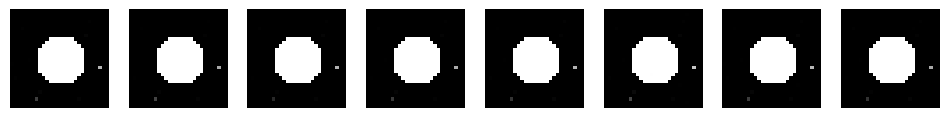

Label 1 (Square):


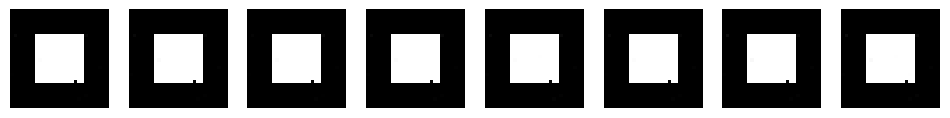

In [ ]:
def show_images(label):
    z = torch.randn(8, noise_dim).to(device)
    labels = torch.full((8,), label).to(device)

    imgs = G(z, labels).detach().cpu()
    imgs = imgs.view(-1, 28, 28)

    fig, axes = plt.subplots(1, 8, figsize=(12,2))
    for i, ax in enumerate(axes):
        ax.imshow(imgs[i], cmap='gray')
        ax.axis('off')
    plt.show()

print("Label 0 (Circle):")
show_images(0)

print("Label 1 (Square):")
show_images(1)
